## Introduction to Langgraph

In [1]:
# Start by loading environment variables (OpenAI model endpoint and key)
import os

from dotenv import load_dotenv
load_dotenv('.env')
OPENAI_API_ENDPOINT=os.getenv("OPENAI_API_ENDPOINT")
AZURE_OPENAI_DEPLOYMENT_NAME=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME_52")
OPENAI_API_VERSION=os.getenv("OPENAI_API_VERSION")
RESOURCE_TENANT_ID=os.getenv("RESOURCE_TENANT_ID")

In [2]:
# Ensure all API Keys are removed from the environment variables.
# This may be necessary to prevent any default usage of API key variables by Langchain.
os.environ.pop("OPENAI_API_KEY", None)
os.environ.pop("AZURE_OPENAI_API_KEY", None)

In [3]:
from azure.identity import AzureCliCredential, get_bearer_token_provider

# Run 'azlogin' in terminal...
credential = AzureCliCredential(tenant_id=RESOURCE_TENANT_ID)
token_provider = get_bearer_token_provider(credential, "https://cognitiveservices.azure.com/.default")

### Basic Chatbot
A basic application of langgraph starts with a stategraph. A stategraph object defines the structure of the application. Operations (Agents, functions, etc.) are defined as nodes on the graph and edges are used to define their connections (workflow). Stategraphs are the core to langgraph, and are defined using the START and END nodes.

In [4]:
# Import libraries:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from langchain_openai import AzureChatOpenAI


[TensorFlow DLL Diagnostic] Analyzing: c:\anaconda3\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.


Neither PyTorch nor TensorFlow >= 2.0 have been found.Models won't be available and only tokenizers, configurationand file/data utilities can be used.


In [5]:
# Define a state. Note the use of Annotated here in order to specify to langgraph how the message should be handled:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function in the annotation defines how this state key
    # should be updated (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

# Initiate the stategraph with the defined state:
graph_builder = StateGraph(State)

In [6]:
llm = AzureChatOpenAI(
    azure_deployment=AZURE_OPENAI_DEPLOYMENT_NAME,
    azure_endpoint=OPENAI_API_ENDPOINT,
    azure_ad_token_provider=token_provider,
    api_version=OPENAI_API_VERSION,
)

In [7]:
# Incorporate the chat model into a simple node:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# Add node to the graph. The first argument is the unique node name, and the second is the object that will be called
# whenever the node is used:
graph_builder.add_node("chatbot", chatbot)

In [8]:
# Add start and end nodes to the graph:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [9]:
# Before running the graph, we need to compile it:
graph = graph_builder.compile()

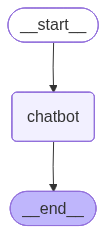

In [10]:
# You can visualize the graph using the get_graph method and one of the "draw" methods:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
# To run the chatbot, first we create the current_state object to persist across turns:
current_state = {"messages": []}

# Then we define the stream function. Note the use of the graph.stream() method to get updates as they happen, and
# the event.values() method to get the updated state from the graph:
def stream_graph_updates(user_input: str):
    global current_state
    # Append the new user message to the persisted messages before streaming
    current_state["messages"] = current_state.get("messages", []) + [{"role": "user", "content": user_input}]

    # Call the graph with the full current state so the node can append the assistant reply
    for event in graph.stream(current_state):
        for value in event.values():
            # value["messages"] is the updated messages list from the graph; persist it
            current_state["messages"] = value["messages"]
            print("Assistant:", current_state["messages"][-1].content)

# Now we can create a basic script to run the chatbot:
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: Here are some widely regarded science fiction works from roughly the last 100 years (mid‑1920s to now), spanning subgenres and mediums. I’m focusing on “great” in the sense of lasting influence, craft, and ideas.

## Novels (and short novels)
- **Aldous Huxley — *Brave New World* (1932)**  
  Classic dystopia about engineered happiness, social control, and consumerism.
- **George Orwell — *Nineteen Eighty-Four* (1949)**  
  The modern template for surveillance-state fiction and political language as control.
- **Ray Bradbury — *Fahrenheit 451* (1953)**  
  A lyrical cautionary tale about censorship, distraction, and shallow media culture.
- **Walter M. Miller Jr. — *A Canticle for Leibowitz* (1959)**  
  Post‑apocalyptic monastic preservation of knowledge; cyclical history and faith vs. tech.
- **Philip K. Dick — *The Man in the High Castle* (1962)** and *Ubik* (1969)  
  Reality instability, paranoia, and power—hugely influential on modern SF and film.
- **Frank Herbert — *

In [12]:
# We can also invoie the Langgraph once without streaming, using the graph.invoke() method:
current_state = {"messages": []}

current_state["messages"] = current_state.get("messages", []) + [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Explain the difference between LangGraph and LangChain."}
]
result = graph.invoke(current_state)
print(result["messages"][-1].content)

LangChain and LangGraph are related libraries (both from LangChain) but they target different ways of building LLM applications.

## LangChain (library/framework)
**What it is:** A general-purpose toolkit for building LLM apps using *components* you compose.
- Provides building blocks like: **prompt templates, chat models, output parsers, tools, retrievers/vector stores, memory utilities**, etc.
- Common pattern: **a “chain”** (linear-ish pipeline) such as *retrieve → prompt → LLM → parse*.
- Best for: straightforward workflows, RAG pipelines, tool calling setups, and quick composition of LLM features.

**Mental model:** “Compose reusable components into a pipeline.”

## LangGraph (orchestration/runtime for agents as graphs)
**What it is:** A framework for building **stateful, multi-step agent workflows** as an explicit **graph/state machine**.
- You define nodes (steps/agents/tools), edges (transitions), and a **shared state** that evolves.
- Supports **loops, branching, retries, cond

### Adding tools to your AI application
We'll add the ability for our AI to search the web using a tool. The tool will access the Tavily search engine, a search engine specifically designed for AI factual research.

In [11]:
from langchain_tavily import TavilySearch
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [12]:
# Define the search tool:
tool = TavilySearch(max_results=2)
tools = [tool]

# Check to see that the tool works:
tool.invoke("Who won the nobel peace prize for physics in 2025?")

{'query': 'Who won the nobel peace prize for physics in 2025?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.youtube.com/watch?v=m9FUkAis62s',
   'title': 'Announcement of the 2025 Nobel Prize in Physics - YouTube',
   'content': 'The Nobel Prize in Physics 2025 was awarded to John Clarke, Michel H. Devoret and John M. Martinis "for the discovery of macroscopic quantum',
   'score': 0.9967013,
   'raw_content': None},
  {'url': 'https://www.nobelprize.org/prizes/physics/2025/summary/',
   'title': 'Nobel Prize in Physics 2025 - NobelPrize.org',
   'content': '## Nobel Prize in Physics 2025. # Nobel Prize. ### John Clarke. ### Michel H. ### John M. The Nobel Prize in Physics 2025 was awarded jointly to John Clarke, Michel H. Martinis "for the discovery of macroscopic quantum mechanical tunnelling and energy quantisation in an electric circuit". MLA style: Nobel Prize in Physics 2025. ## Nobel Prizes and laureates. Six prizes were awarde

In [13]:
# Create a node class that calls the tool when invoked. The node checks the most recent message in the state
# and calls tools if the message contains tool_calls. It relies on the LLM's tool_calling support, which comes
# built in with multiple LLM model providers.
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        ''' Set of tools by name and the defined tool. '''
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        ''' Define tool's call behavior. '''
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}

# Create the tool node:
tool_node = BasicToolNode(tools=[tool])

In [14]:
# Let's define a new stategraph and add the tools to it. Start by binding tools to the same LLM object
# we defined before:
llm_with_tools = llm.bind_tools(tools)
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [15]:
# Add nodes to the graph:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", tool_node)

In [16]:
# Add conditional edges. Conditional edges determine the processing path through the graph, usually based
# on the current state. These functions take the current state and returns a string or list of strings indicating
# the next node(s) to process. 
def route_tools(state: State):
    """
    Use in the conditional_edge to route to the ToolNode if the last message has tool calls; otherwise route to END.
    """
    # Extract the last message from the state:
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    # Conditional routing based on whether the last message from the LLM has tool calls:
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    else:
        return END

# Add the conditional edge to the graph using the `route_tools` function. As can be seen, this function returns
# "tools" if the chatbot asks to use a tool and "END" if it is fine directly responding.
graph_builder.add_conditional_edges(
    "chatbot", route_tools,
    # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node.
    {"tools": "tools", END: END},
)

In [17]:
# Complete the graph by adding final connecting edges. Any time a tool is called, we return to the chatbot
# to decide the next step. Note that we don't need to add END as it is already handled in the conditional edge above.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

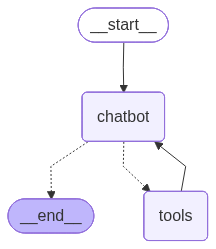

In [ ]:
# Visualize the updated graph as before:
display(Image(graph.get_graph().draw_mermaid_png()))
#print(graph.get_graph().draw_ascii())  ## This is another way to visualize, if draw_mermaid doesn't work.

In [20]:
# Let's try the chatbot as before:
current_state = {"messages": []}

def stream_graph_updates(user_input: str):
    global current_state
    current_state["messages"] = current_state.get("messages", []) + [{"role": "user", "content": user_input}]

    print(f'\n--------------------------------\nUser: {user_input}\n')
    for event in graph.stream(current_state):
        for value in event.values():
            current_state["messages"] = value["messages"]
            print("Assistant:", current_state["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break


--------------------------------
User: Tell me about the nobel prize

Assistant: The **Nobel Prize** is a set of international awards established by the will of Swedish inventor **Alfred Nobel** (who died in 1896). They honor people and organizations whose work has provided “the greatest benefit to humankind.”

## Prize categories
Originally (first awarded in **1901**):
- **Physics**
- **Chemistry**
- **Physiology or Medicine**
- **Literature**
- **Peace**

Added later:
- **Sveriges Riksbank Prize in Economic Sciences in Memory of Alfred Nobel** (often called the “Nobel Prize in Economics”), first awarded in **1969**. It’s Nobel-associated but not one of the original prizes in Nobel’s will.

## Who awards them
- **Royal Swedish Academy of Sciences**: Physics, Chemistry, Economics
- **Nobel Assembly at Karolinska Institutet**: Physiology or Medicine
- **Swedish Academy**: Literature
- **Norwegian Nobel Committee**: Peace (awarded in Norway, unlike the others in Sweden)

## How it works

### Adding Memory using persistent checkpoints
So far we've been manually maintaining the message history by creating a global `current_state` variable and iterativelly updating it during event streaming. This can be handled much more efficiently persistent checkpoints.

By provide a `checkpointer` when compiling the graph and a `thread_id` when calling your graph, LangGraph automatically saves the state after each step. When you invoke the graph again using the same thread_id, the graph loads its saved state, allowing the chatbot to pick up where it left off.

In [21]:
# Create a memory checkpointer. The InMemorySaver stores checkpoints in memory. For production use,
# consider using a more persistent storage solution, such as a database or file system.
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()

In [22]:
# Compile the graph with the checkpointer, which will checkpoint the State as the graph works through each node:
graph = graph_builder.compile(checkpointer=memory)

In [23]:
# Let's call the chatbot again, this time providing a thread_id to persist the state across calls:
config = {"configurable": {"thread_id": "1"}}

# Event stream again, but this time the state is automatically loaded and saved by the checkpointer:
def stream_graph_updates(user_input: str):
    print(f'\n--------------------------------\nUser: {user_input}\n')
    # The config variable is the second positional argument for the stream() or invoke() functions
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}, config):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    stream_graph_updates(user_input)


--------------------------------
User: Tell me about some global current events

Assistant: 
Assistant: {"query": "global current events May 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newsweek.com/videos/the-bulletin-may-18s-news-in-60-seconds", "title": "The Bulletin: May 18\u2019s News in 60 seconds - Newsweek", "score": 0.829092264175415, "published_date": "Mon, 18 May 2026 15:20:51 GMT", "content": "Russia-UkraineMiddle EastChina And AsiaLive BlogBetter PlanetAll World News. The Bulletin: May 18\u2019s News in 60 seconds. MAY 18, 2026 at 11:20 AM EDT. Meanwhile, the World Health Organization has declared the Ebola outbreak in Central Africa a global health emergency as deaths rise and vaccine shortages fuel concern. In Eastern Europe, Volodymyr Zelenskyy says Ukr... ## The Sports Gambling Experiment Has Failed \u2014 What Can We Do About It? ## Real Reason F1 Cars Are Slower In 2026. ## Ex Prince Andrew Kicked His Dog and Gro

In [24]:
# We can inspect the state saved in memory by using graph.get_state():
snapshot = graph.get_state(config)
snapshot.values

{'messages': [HumanMessage(content='Tell me about some global current events', additional_kwargs={}, response_metadata={}, id='faceb2a7-9ff1-4288-ba10-6b0c840843c3'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 1275, 'total_tokens': 1315, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}, 'latency_checkpoint': {'engine_tbt_ms': 14, 'engine_ttft_ms': 105, 'engine_ttlt_ms': 647, 'pre_inference_ms': 151, 'service_tbt_ms': 14, 'service_ttft_ms': 435, 'service_ttlt_ms': 971, 'total_duration_ms': 831, 'user_visible_ttft_ms': 284}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DhMSdl5bEF4msm7Xzs76LhY1ujJyq', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'con